In [5]:
import pandas as pd

df = pd.read_csv("../data/Books_rating.csv", nrows=100000)

df = df[["Title", "review/score", "review/text", "review/time"]]
df = df.dropna()
df = df.rename(columns={
    "review/score": "rating",
    "review/text": "review",
    "review/time": "review_time"
})

df = df.sample(20000, random_state=42)

df.to_csv("../data/sample_books.csv", index=False)
print(df.head())
print(df.columns)

                                                   Title  rating  \
26003                         Candide and Other Writings     5.0   
80421  The romance of Leonardo da Vinci (Modern libra...     5.0   
19865                      One Hundred Years of Solitude     5.0   
81526  Acquiring Genomes: A Theory Of The Origins Of ...     5.0   
57879                           Into the Wild (Warriors)     5.0   

                                                  review  review_time  
26003  I have always been fond of satire. Candide is ...   1029628800  
80421  Many years ago I was required to read "The Rom...   1292284800  
19865  I have not read a book as good as One Hundred ...   1022457600  
81526  In Acquiring Genomes, authors Lynn Margulis &a...   1039219200  
57879  In this beginning book in the series Warriors,...   1180915200  
Index(['Title', 'rating', 'review', 'review_time'], dtype='str')


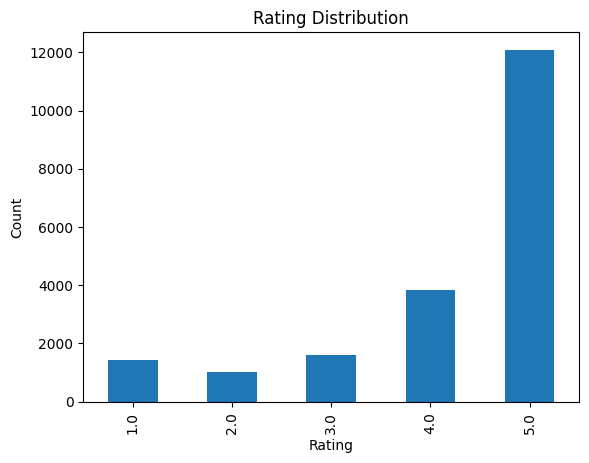

In [6]:
import matplotlib.pyplot as plt

df['rating'].value_counts().sort_index().plot(kind='bar')
plt.title("Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()

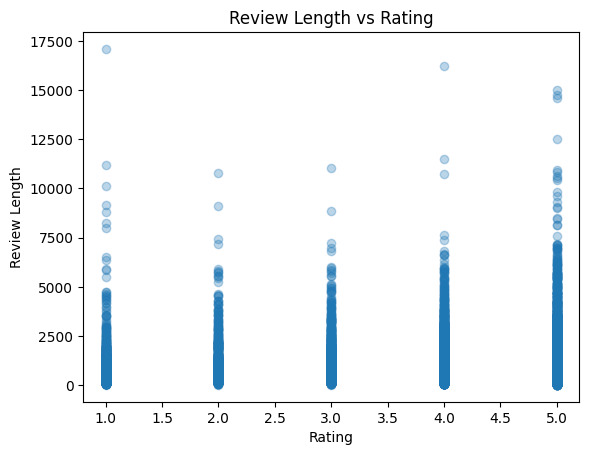

In [7]:
df['review_length'] = df['review'].astype(str).apply(len)

plt.scatter(df['rating'], df['review_length'], alpha=0.3)
plt.title("Review Length vs Rating")
plt.xlabel("Rating")
plt.ylabel("Review Length")
plt.show()

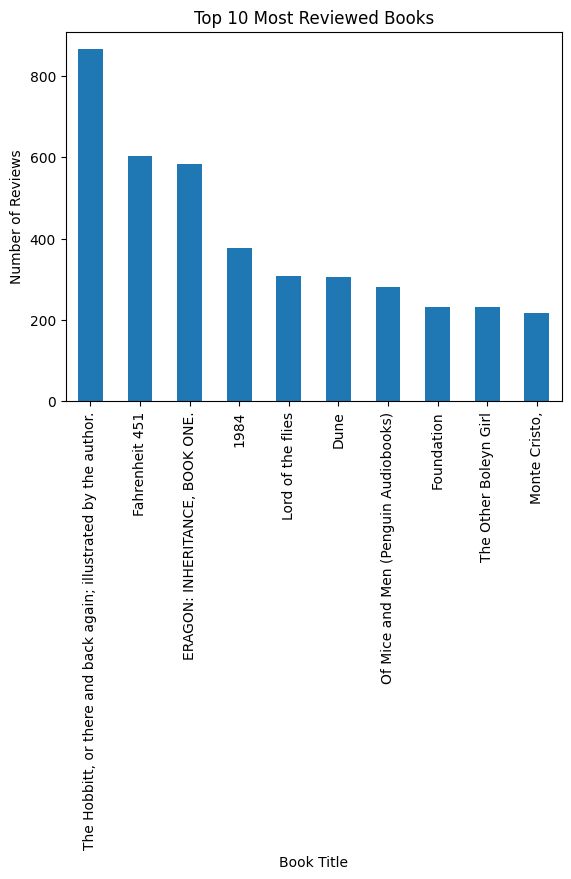

In [8]:
df['Title'].value_counts().head(10).plot(kind='bar')
plt.title("Top 10 Most Reviewed Books")
plt.xlabel("Book Title")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=90)
plt.show()

### 📊 EDA Findings

1. The rating distribution is highly skewed toward positive values, with ratings of 4 and especially 5 dominating the dataset. This indicates that most users tend to leave positive reviews.

2. Lower ratings (1 and 2) are significantly less frequent, suggesting either a positive bias in reviews or that users are more likely to rate books they enjoy.

3. The relationship between review length and rating does not show a strong clear pattern; however, higher ratings (especially 4 and 5) tend to include many long reviews, indicating that satisfied users often provide detailed feedback.

4. Review lengths vary widely across all rating levels, meaning both short and long reviews can be either positive or negative.

5. Some books appear much more frequently than others in the dataset (e.g., popular titles like *Fahrenheit 451* and *1984*), indicating that the dataset contains a mix of highly popular and less-reviewed books.

6. The dataset is suitable for sentiment analysis since it contains both textual reviews and corresponding numerical ratings, which can be used to generate sentiment labels.